In [1]:
pip install pillow earthengine-api geemap matplotlib numpy pandas rasterio scikit-learn tensorflow tqdm

  Using cached google_auth_httplib2-0.2.0-py2.py3-none-any.whl.metadata (2.2 kB)
  Using cached httplib2-0.22.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached uritemplate-4.1.1-py2.py3-none-any.whl.metadata (2.9 kB)
  Using cached rsa-4.9-py3-none-any.whl.metadata (4.2 kB)
  Using cached namex-0.0.8-py3-none-any.whl.metadata (246 bytes)
  Using cached t

#### Code to pull Landsat images for Fire (with filter) and non-Fire from Australia between November 2019 and February 2020

In [34]:
ee.Authenticate()


Successfully saved authorization token.


In [35]:
import ee
import geemap
import pandas as pd
from tqdm import tqdm
import datetime
import os

# -------------------------------------
# Step 1: Setup
# -------------------------------------
ee.Initialize()

# Load fire points
df = pd.read_csv("viirs_firepoints_cleaned.csv")
df = df.dropna(subset=["latitude", "longitude", "date"])
df["date"] = pd.to_datetime(df["date"])
df = df.head(1000)  # Limit to 500 fire points

# Create output directory
output_dir = "fire_patches"
os.makedirs(output_dir, exist_ok=True)

# Track how many valid patches we actually get
valid_count = 0

# -------------------------------------
# Step 2: Loop through each fire point
# -------------------------------------
for idx, row in tqdm(df.iterrows(), total=len(df)):
    lat, lon = row["latitude"], row["longitude"]
    fire_date = row["date"]

    print(f"\n🔥 Processing patch {idx+1}/{len(df)}")
    print(f"📍 Location: ({lat:.4f}, {lon:.4f})")
    print(f"📅 Fire date: {fire_date.date()}")

    try:
        # Create ±3 day date range
        start = fire_date - pd.Timedelta(days=3)
        end = fire_date + pd.Timedelta(days=3)

        # GEE geometry
        point = ee.Geometry.Point([lon, lat])
        buffer = point.buffer(500)  # 500-meter buffer

        print("🔍 Searching Landsat 8 images...")
        landsat = (
            ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
            .filterBounds(point)
            .filterDate(str(start.date()), str(end.date()))
            .filterMetadata("CLOUD_COVER", "less_than", 10)
            .sort("CLOUD_COVER")
        )

        # Check if collection is empty
        if landsat.size().getInfo() == 0:
            print("⚠️ No valid Landsat image found for this point.")
            continue

        # Get the best image
        image = ee.Image(landsat.first())
        export_img = image.select(["SR_B4", "SR_B5", "SR_B6", "SR_B7"]).clip(buffer)

        # Export filename
        filename = os.path.join(output_dir, f"landsat_fire_patch_{valid_count}.tif")
        print(f"💾 Exporting to: {filename}...")

        # Export image to local disk
        geemap.ee_export_image(
            export_img,
            filename=filename,
            scale=30,
            region=buffer.bounds().getInfo()["coordinates"],
            file_per_band=False
        )

        print(f"✅ Successfully saved {filename}")
        valid_count += 1

    except Exception as e:
        print(f"❌ Error while processing patch {idx}: {e}")

# -------------------------------------
# Step 3: Done
# -------------------------------------
print(f"\n🎉 Downloaded {valid_count} valid fire patches to '{output_dir}' folder.")


  0%|          | 0/1000 [00:00<?, ?it/s]


🔥 Processing patch 1/1000
📍 Location: (-32.9596, 116.4581)
📅 Fire date: 2019-11-01
🔍 Searching Landsat 8 images...


  0%|          | 1/1000 [00:00<07:39,  2.17it/s]

⚠️ No valid Landsat image found for this point.

🔥 Processing patch 2/1000
📍 Location: (-32.9506, 116.4677)
📅 Fire date: 2019-11-01
🔍 Searching Landsat 8 images...


  0%|          | 2/1000 [00:00<07:06,  2.34it/s]

...

Data downloaded to c:\Users\leeju\Downloads\csprojtest\csprojtest\landsat\fire_patches\landsat_fire_patch_411.tif
✅ Successfully saved fire_patches\landsat_fire_patch_411.tif

🔥 Processing patch 999/1000
📍 Location: (-27.3029, 128.9115)
📅 Fire date: 2019-11-07
🔍 Searching Landsat 8 images...
💾 Exporting to: fire_patches\landsat_fire_patch_412.tif...
Generating URL ...
Please wait ...


100%|█████████▉| 999/1000 [16:23<00:01,  1.73s/it]

Data downloaded to c:\Users\leeju\Downloads\csprojtest\csprojtest\landsat\fire_patches\landsat_fire_patch_412.tif
✅ Successfully saved fire_patches\landsat_fire_patch_412.tif

🔥 Processing patch 1000/1000
📍 Location: (-27.1545, 128.7651)
📅 Fire date: 2019-11-07
🔍 Searching Landsat 8 images...
💾 Exporting to: fire_patches\landsat_fire_patch_413.tif...
Generating URL ...
Please wait ...


100%|██████████| 1000/1000 [16:24<00:00,  1.02it/s]

Data downloaded to c:\Users\leeju\Downloads\csprojtest\csprojtest\landsat\fire_patches\landsat_fire_patch_413.tif
✅ Successfully saved fire_patches\landsat_fire_patch_413.tif

🎉 Downloaded 414 valid fire patches to 'fire_patches' folder.


In [ ]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Config
folder = "landsat_fire_patches"
IMG_SIZE = (64, 64)  # Resize for display
columns = 6          # Number of images per row

# List all .tif files
tif_files = sorted([f for f in os.listdir(folder) if f.endswith(".tif")])
total = len(tif_files)
rows = (total + columns - 1) // columns

def normalize_band(band):
    band = band.astype(np.float32)
    return (band - band.min()) / (band.max() - band.min() + 1e-6)

# Plot all images
plt.figure(figsize=(columns * 2.2, rows * 2.2))
for i, fname in enumerate(tif_files):
    path = os.path.join(folder, fname)
    try:
        with rasterio.open(path) as src:
            b4 = normalize_band(src.read(1))  # Red
            b5 = normalize_band(src.read(2))  # NIR
            b6 = normalize_band(src.read(3))  # SWIR1

            # SWIR1-NIR-Red composite
            rgb = np.stack([b6, b5, b4], axis=-1)
            rgb = Image.fromarray((rgb * 255).astype(np.uint8)).resize(IMG_SIZE)

        plt.subplot(rows, columns, i + 1)
        plt.imshow(rgb)
        plt.title(fname.split('.')[0], fontsize=8)
        plt.axis("off")
    except Exception as e:
        print(f"❌ Error loading {fname}: {e}")

plt.tight_layout()
plt.suptitle("🔥 All Fire-Confirmed Landsat Patches", fontsize=18, y=1.01)
plt.show()


In [36]:
import ee
import geemap
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import os

# Initialize Earth Engine
ee.Initialize()

# Create output directory
output_dir = "nofire_patches"
os.makedirs(output_dir, exist_ok=True)

# Load fire point data
fire_df = pd.read_csv("viirs_firepoints_cleaned.csv")
fire_df['date'] = pd.to_datetime(fire_df['date'])

# Filter for Nov 2019 – Feb 2020
fire_df = fire_df[
    (fire_df['date'] >= "2019-11-01") &
    (fire_df['date'] <= "2020-02-29")
]

# Step 1: Generate 155 offset coordinates away from fire clusters
coords = fire_df[['longitude', 'latitude']].dropna()
k = 414
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(coords)

offset = 1.5  # Degrees to shift away (~150km)
nofire_coords = [[lon + offset, lat + offset] for lon, lat in kmeans.cluster_centers_]

# Step 2: Export no-fire Landsat patches from those coords
def export_nofire_patch(lat, lon, patch_id, buffer_m=1000):
    try:
        point = ee.Geometry.Point([lon, lat]).buffer(buffer_m)
        image = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
                 .filterBounds(point)
                 .filterDate("2019-11-01", "2020-02-29")
                 .filter(ee.Filter.lt("CLOUD_COVER", 20))
                 .sort("CLOUD_COVER")
                 .first())

        if image is None:
            print(f"⚠️ No image found at {lat}, {lon}")
            return

        clipped = image.clip(point)
        geemap.ee_export_image(
            clipped.select(['SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']),
            filename=os.path.join(output_dir, f"nofire_{patch_id}.tif"),
            scale=30,
            region=point.bounds().getInfo()['coordinates'],
            file_per_band=False
        )
        print(f"✅ Exported nofire_{patch_id}.tif")

    except Exception as e:
        print(f"❌ Failed to export nofire_{patch_id}: {e}")

# Step 3: Loop to download all 155 no-fire patches
for i, (lon, lat) in enumerate(nofire_coords):
    export_nofire_patch(lat, lon, i)


Generating URL ...
Please wait ...
Data downloaded to c:\Users\leeju\Downloads\csprojtest\csprojtest\landsat\nofire_patches\nofire_0.tif
✅ Exported nofire_0.tif
Generating URL ...
Please wait ...
Data downloaded to c:\Users\leeju\Downloads\csprojtest\csprojtest\landsat\nofire_patches\nofire_1.tif
✅ Exported nofire_1.tif
Generating URL ...
Please wait ...
Data downloaded to c:\Users\leeju\Downloads\csprojtest\csprojtest\landsat\nofire_patches\nofire_2.tif
✅ Exported nofire_2.tif
Generating URL ...
Please wait ...
Data downloaded to c:\Users\leeju\Downloads\csprojtest\csprojtest\landsat\nofire_patches\nofire_3.tif
✅ Exported nofire_3.tif
Generating URL ...
Please wait ...
Data downloaded to c:\Users\leeju\Downloads\csprojtest\csprojtest\landsat\nofire_patches\nofire_4.tif
✅ Exported nofire_4.tif
Generating URL ...
Please wait ...
Data downloaded to c:\Users\leeju\Downloads\csprojtest\csprojtest\landsat\nofire_patches\nofire_5.tif
✅ Exported nofire_5.tif
Generating URL ...
Please wait ...

#### CNN Model to Predict Fire based on image

In [40]:
import os
import numpy as np
import rasterio
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

# -----------------------
# Config
# -----------------------
IMG_SIZE = (128, 128)
BANDS = 4
fire_dir = "fire_patches"
nofire_dir = "nofire_patches"

# -----------------------
# Helper: Normalize band
# -----------------------
def normalize_band(band):
    band = band.astype(np.float32)
    return (band - band.min()) / (band.max() - band.min() + 1e-6)

# -----------------------
# Helper: Load images
# -----------------------
def load_tif_images_from_folder(folder, label):
    X, y = [], []
    for fname in sorted(os.listdir(folder)):
        if not fname.endswith(".tif"):
            continue
        path = os.path.join(folder, fname)
        try:
            with rasterio.open(path) as src:
                if src.count < BANDS:
                    continue
                bands = []
                for i in range(BANDS):
                    band = normalize_band(src.read(i + 1))
                    resized = Image.fromarray((band * 255).astype(np.uint8)).resize(IMG_SIZE)
                    bands.append(np.array(resized) / 255.0)
                img = np.stack(bands, axis=-1)
                X.append(img)
                y.append(label)
        except Exception as e:
            print(f"❌ Error loading {fname}: {e}")
    return np.array(X), np.array(y)

# -----------------------
# Load fire and no-fire data
# -----------------------
X_fire, y_fire = load_tif_images_from_folder(fire_dir, label=1)
X_nofire, y_nofire = load_tif_images_from_folder(nofire_dir, label=0)

# Combine
X_all = np.concatenate([X_fire, X_nofire])
y_all = np.concatenate([y_fire, y_nofire])


In [41]:
# Helper function: Convert 4-band to 3-band (RGB style)
def convert_4band_to_rgb(img_4band):
    return img_4band[:, :, [2, 1, 0]]  # SWIR1, NIR, RED

X_all_rgb = convert_4band_to_rgb(X_all)

In [43]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import rasterio
from PIL import Image
import matplotlib.pyplot as plt

# -----------------------
# Load the Dataset
# -----------------------
# Directories
fire_dir = "fire_patches"
nofire_dir = "nofire_patches"

# Image size for display and training
IMG_SIZE = (128, 128)
BANDS = 4  # Red, NIR, SWIR1, SWIR2

# Normalize image band
def normalize_band(band):
    band = band.astype(np.float32)
    return (band - band.min()) / (band.max() - band.min() + 1e-6)

# Convert 4-band to RGB (using SWIR1, NIR, Red)
def convert_4band_to_rgb(img_4band):
    return img_4band[:, :, [2, 1, 0]]  # SWIR1 (B6), NIR (B5), Red (B4)

# Helper: Load images from directory
def load_tif_images_from_folder(folder, label):
    X, y = [], []
    for fname in sorted(os.listdir(folder)):
        if not fname.endswith('.tif'):
            continue
        path = os.path.join(folder, fname)
        try:
            with rasterio.open(path) as src:
                if src.count < BANDS:
                    continue
                bands = []
                for i in range(BANDS):
                    band = normalize_band(src.read(i + 1))
                    resized = Image.fromarray((band * 255).astype(np.uint8)).resize(IMG_SIZE)
                    bands.append(np.array(resized) / 255.0)
                img = np.stack(bands, axis=-1)
                X.append(img)
                y.append(label)
        except Exception as e:
            print(f"❌ Error loading {fname}: {e}")
    return np.array(X), np.array(y)



In [44]:
# Load fire and no-fire data
X_fire, y_fire = load_tif_images_from_folder(fire_dir, label=1)
X_nofire, y_nofire = load_tif_images_from_folder(nofire_dir, label=0)

# Combine data
X_all = np.concatenate([X_fire, X_nofire])
y_all = np.concatenate([y_fire, y_nofire])

# Convert 4-band to 3-band (RGB)
X_all_rgb = np.array([convert_4band_to_rgb(img) for img in X_all])

# -----------------------
# Split Data into Train/Test
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_all_rgb, y_all, test_size=0.2, stratify=y_all, random_state=42
)

# -----------------------
# Data Augmentation
# -----------------------
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 203ms/step - accuracy: 0.5306 - loss: 0.7179 - val_accuracy: 0.5875 - val_loss: 0.6508 - learning_rate: 0.0010
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.6517 - loss: 0.6182 - val_accuracy: 0.6187 - val_loss: 0.6081 - learning_rate: 0.0010
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 187ms/step - accuracy: 0.6611 - loss: 0.5700 - val_accuracy: 0.7250 - val_loss: 0.5212 - learning_rate: 0.0010
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 181ms/step - accuracy: 0.7002 - loss: 0.5157 - val_accuracy: 0.7063 - val_loss: 0.4461 - learning_rate: 0.0010
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - accuracy: 0.7502 - loss: 0.4709 - val_accuracy: 0.6562 - val_loss: 0.5133 - learning_rate: 0.0010
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 190ms/step - accuracy: 0.7867 - loss: 0.4277 - val_accuracy: 0.9312 - val_loss: 0.2649 - learning_rate: 0.0010
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 182ms/step - accuracy: 0.8392 - loss: 0.3897 - 

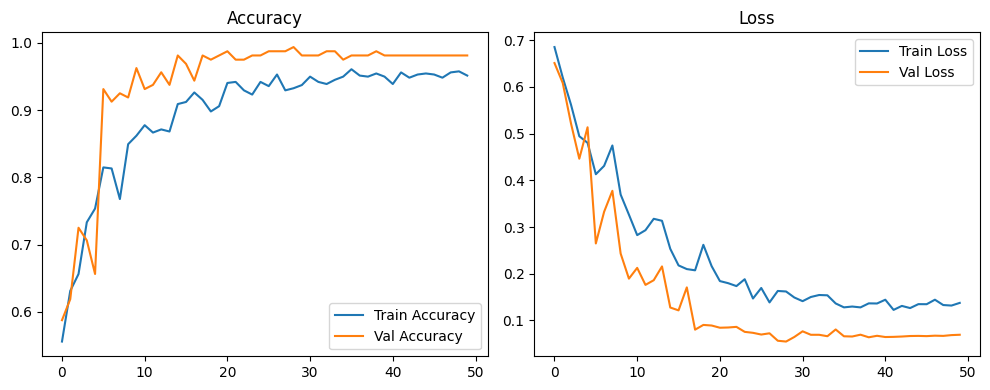

In [46]:
# -----------------------
# CNN Model
# -----------------------
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),  # 3 channels (RGB)
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # Binary classification (fire vs no-fire)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# -----------------------
# Early Stopping and Learning Rate Scheduling
# -----------------------
#early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

# -----------------------
# Train Model with Augmentation
# -----------------------
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=50,
    callbacks=[lr_schedule]
)

# -----------------------
# Evaluate
# -----------------------
loss, acc = model.evaluate(X_test, y_test)
print(f"🎯 Final Test Accuracy: {acc*100:.2f}%")

# -----------------------
# Plot Accuracy and Loss
# -----------------------
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


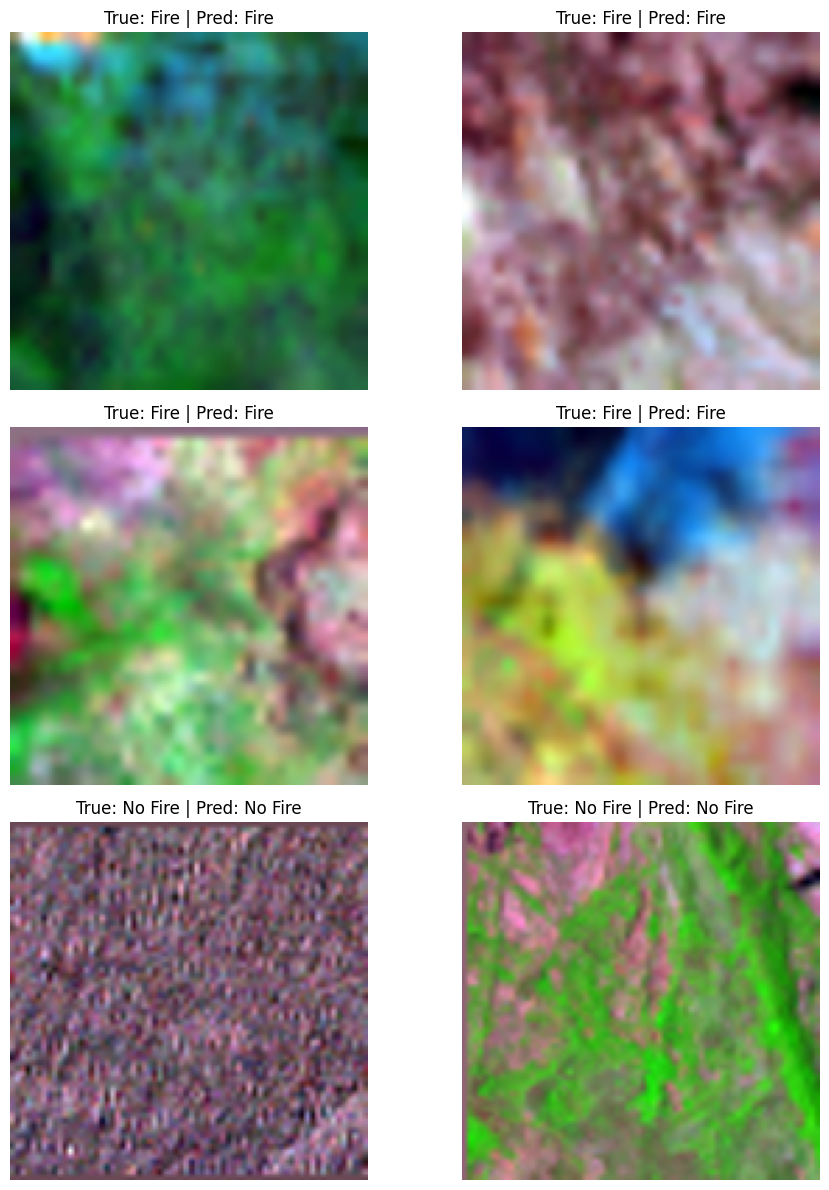

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Select some test samples
test_samples = np.random.choice(len(X_test), 6, replace=False)  # 6 random samples

# Create a figure with 3 rows and 2 columns (for 6 samples)
plt.figure(figsize=(10, 12))

for i, idx in enumerate(test_samples):
    img = X_test[idx]
    true_label = y_test[idx]
    
    # Make prediction (probability)
    pred_prob = model.predict(np.expand_dims(img, axis=0))
    pred_label = (pred_prob > 0.5).astype(int)

    # Plot the image and its prediction
    plt.subplot(3, 2, i + 1)
    plt.imshow(img)
    plt.title(f"True: {'Fire' if true_label == 1 else 'No Fire'} | Pred: {'Fire' if pred_label == 1 else 'No Fire'}")
    plt.axis("off")

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━

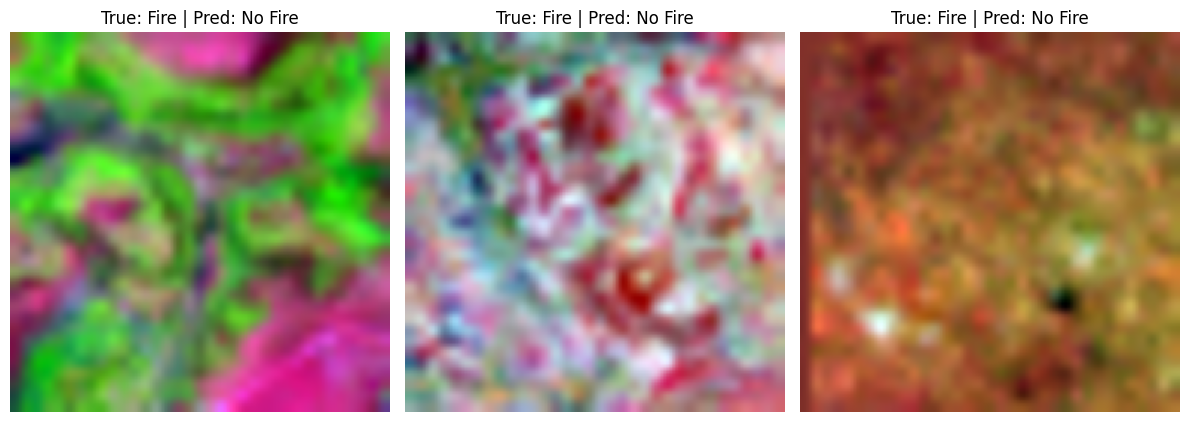

In [49]:
# Identify misclassified samples
misclassified = []

for i in range(len(X_test)):
    img = X_test[i]
    true_label = y_test[i]
    
    # Make prediction
    pred_prob = model.predict(np.expand_dims(img, axis=0))
    pred_label = (pred_prob > 0.5).astype(int)
    
    # Check if misclassified
    if pred_label != true_label:
        misclassified.append((img, true_label, pred_label))

# Display misclassified images
plt.figure(figsize=(12, 10))

for i, (img, true_label, pred_label) in enumerate(misclassified[:6]):  # Show first 6 misclassifications
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"True: {'Fire' if true_label == 1 else 'No Fire'} | Pred: {'Fire' if pred_label == 1 else 'No Fire'}")
    plt.axis("off")

plt.tight_layout()
plt.show()
